In [3]:
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import folium
from folium.plugins import HeatMap
import numpy as np
import pandas as pd
import datetime
import os
from mecoda_minka import get_obs, get_dfs
from docx.shared import Inches, Pt, RGBColor
from docx import Document

In [4]:
api_path = 'https://api.minka-sdg.org/v1'

Primera parte : Obtención y graficación de las observaciones comparando datos anuales

In [ ]:
def get_data(project_id:int, year:bool):

    today = datetime.date.today()

    if year is True:
        df_obs = pd.DataFrame(get_obs(id_project=project_id, grade = 'research',year = today.year))
        dates = pd.to_datetime(df_obs[4].map(lambda x: x[1]))
    else:
        df_obs = pd.DataFrame(get_obs(id_project=project_id, grade = 'research',year = today.year - 1))
        dates = pd.to_datetime(df_obs[4].map(lambda x: x[1]))

    return dates

In [ ]:
def get_data1(project_id:int, year:int):

    if year >= 2021 and year <= datetime.date.today().year:

        print('Executing code...')
        df_obs = pd.DataFrame(get_obs(id_project=project_id, grade = 'research',year = year))
        dates = pd.to_datetime(df_obs[4].map(lambda x: x[1]))

        return dates

    else:
        print('Year is not valid. Please enter a year between 2021 and the current year.')

    

In [1]:
def get_data2(project_id:int):
    
    today = datetime.date.today()

    df_obs_ty = pd.DataFrame(get_obs(id_project=project_id, grade = 'research',year = today.year))
    dates_ty = pd.to_datetime(df_obs_ty[4].map(lambda x: x[1]))

    df_obs_ly = pd.DataFrame(get_obs(id_project=project_id, grade = 'research',year = today.year - 1))
    dates_ly = pd.to_datetime(df_obs_ly[4].map(lambda x: x[1]))

    return dates_ty, dates_ly

In [ ]:
obs = get_data(264, year=False)

In [ ]:
obs1 = get_data1(264, year=2025)

In [4]:
obs2 = get_data2(264)

Generating list of observations:
https://api.minka-sdg.org/v1/observations?project_id=264&year=2025&quality_grade=research&per_page=200
Total observations to download: 222
Number of elements: 200
Number of elements: 222
Generating list of observations:
https://api.minka-sdg.org/v1/observations?project_id=264&year=2024&quality_grade=research&per_page=200
Total observations to download: 2246
Number of elements: 200
Number of elements: 400
Number of elements: 600
Number of elements: 800
Number of elements: 1000
Number of elements: 1200
Number of elements: 1400
Number of elements: 1600
Number of elements: 1800
Number of elements: 2000
Number of elements: 2200
Number of elements: 2246


In [5]:
def plot_obs(dataframe:pd.DataFrame, year:int):

    plt.figure(figsize=(14, 6))
    sns.histplot(data = dataframe , 
                 color = 'blue',
                edgecolor = 'black',
                bins=12,
                kde = True)

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
    plt.title('Distribution of Observations', fontsize = 16)
    plt.legend(['Observations'], fontsize = 12)
    plt.xlabel(f'Year {year}', fontsize = 12)
    plt.ylabel('Observations count', fontsize = 12)
    plt.xticks(rotation=45)
    plt.grid(which = 'major', axis='y', linewidth=0.5, color='black', alpha=0.5)
    plt.title(f'Distribution of Observations in {year}', fontsize = 16)
    plt.savefig(f'obs_{year}.png', dpi=300, bbox_inches='tight')
    return plt.show()

Generating list of observations:
https://api.minka-sdg.org/v1/observations?project_id=264&year=2025&quality_grade=research&per_page=200
Total observations to download: 228
Number of elements: 200
Number of elements: 228
Generating list of observations:
https://api.minka-sdg.org/v1/observations?project_id=264&year=2024&quality_grade=research&per_page=200
Total observations to download: 2246
Number of elements: 200
Number of elements: 400
Number of elements: 600
Number of elements: 800
Number of elements: 1000
Number of elements: 1200
Number of elements: 1400
Number of elements: 1600
Number of elements: 1800
Number of elements: 2000
Number of elements: 2200
Number of elements: 2246


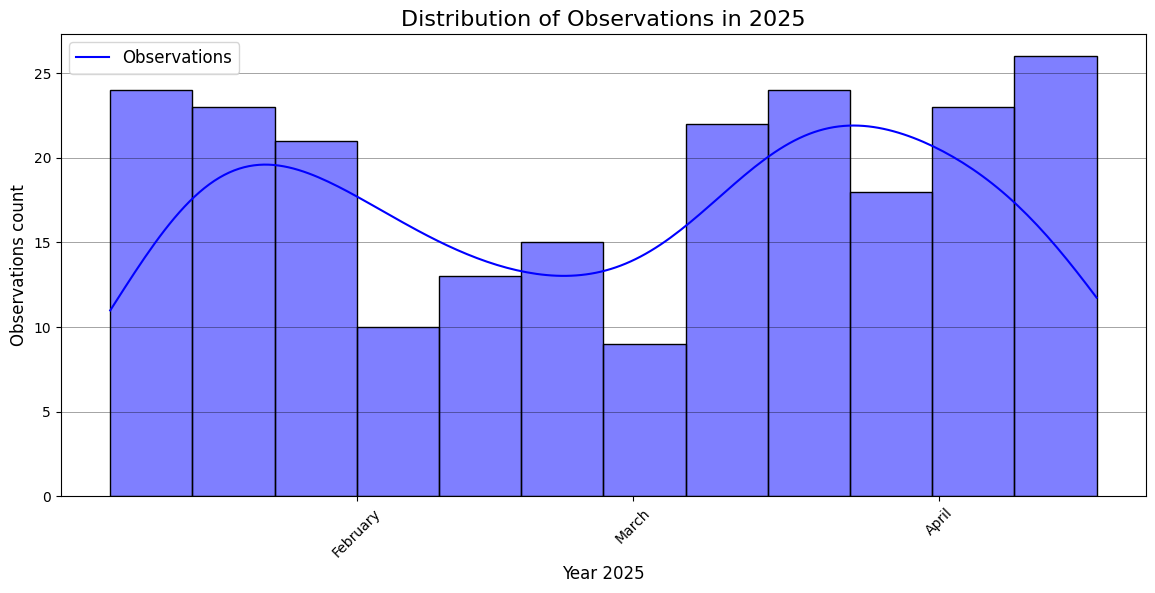

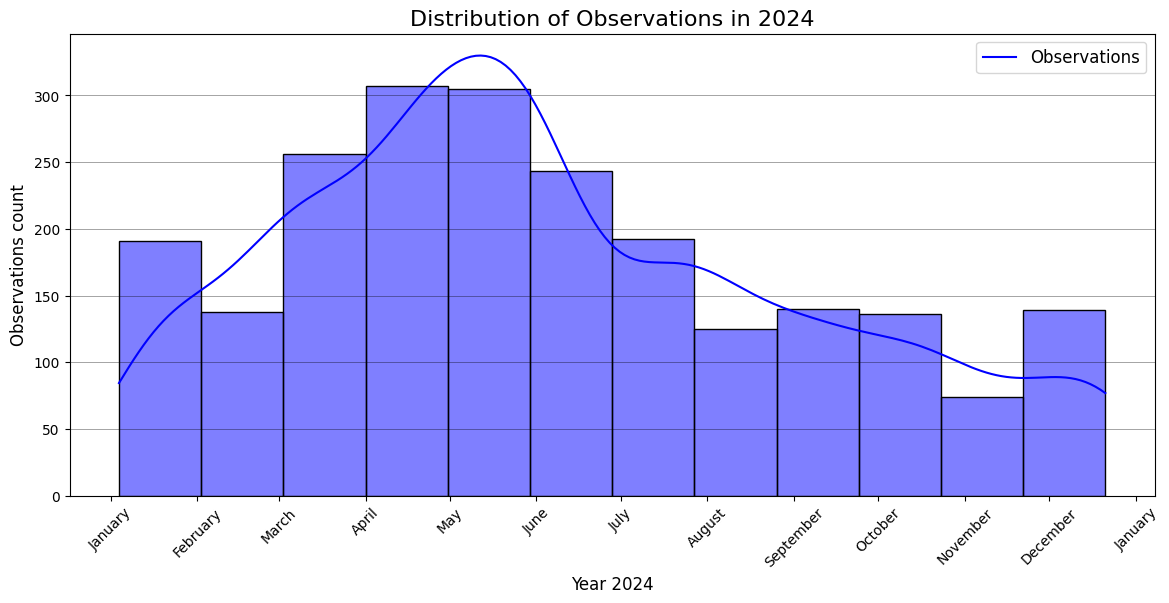

In [6]:
dates_ty, dates_ly = get_data2(264)
plot_obs(dates_ty, 2025)
plot_obs(dates_ly, 2024)

Segunda parte : Obtención metricas anuales (Species, Observadores, Identificadores)

ESPECIES

In [ ]:
def get_total_species(project_id:int, year:bool):

    year = datetime.date.today().year

    species = f'{api_path}/observations/species_counts?'
    
    if year is True:
        url_species = f'{species}&project_id={project_id}&year={year}&quality_grade=research'
        total_species = requests.get(url_species).json()["total_results"]
    else:
        url_species = f'{species}&project_id={project_id}&year={year-1}&quality_grade=research'
        
        total_species = requests.get(url_species).json()["total_results"]

    return total_species


In [ ]:
def get_total_species1(project_id:int, year:int):

    if year >= 2021 and year <= datetime.date.today().year:

        species = f'{api_path}/observations/species_counts?'
        url_species = f'{species}&project_id={project_id}&year={year}&quality_grade=research'
        
        total_species = requests.get(url_species).json()["total_results"]

        return total_species

    else:
        print('Year is not valid. Please enter a year between 2021 and the current year.')

In [ ]:
def get_sum_species_year(project_id:int):
    
    year = datetime.date.today().year
    species = f'{api_path}/observations/species_counts?'
    
    url_species_ty = f'{species}&project_id={project_id}&year={year}&quality_grade=research'
    url_species_ly = f'{species}&project_id={project_id}&year={year-1}&quality_grade=research'
    
    sum_species_ty = requests.get(url_species_ty).json()['results']
    sum_species_ly = requests.get(url_species_ly).json()['results']

    data_ty = []
    data_ly = []
    
    for i in range (len(sum_species_ty)):
        count = sum_species_ty[i]['count']
        name = sum_species_ty[i]['taxon']['name']

        if count >= 10:
            data_ty.append([name, count])
    
    
    for i in range (len(sum_species_ly)):
        count = sum_species_ly[i]['count']
        name = sum_species_ly[i]['taxon']['name']

        if count >= 10:
            data_ly.append([name, count])

    df_species_ty = pd.DataFrame(data_ty, columns=['Species', 'Count'])
    df_species_ly = pd.DataFrame(data_ly, columns=['Species', 'Count'])


    return df_species_ty, df_species_ly

In [ ]:
get_sum_species_year(264)

In [7]:
def get_sum_species_month(project_id:int):
    
    month = datetime.date.today().month
    year = datetime.date.today().year
    species = f'{api_path}/observations/species_counts?'
    
    url_species_tm = f'{species}&project_id={project_id}&month={month}&year={year}&quality_grade=research'
    url_species_lm = f'{species}&project_id={project_id}&month={month}&year={year-1}&quality_grade=research'
    
    sum_species_tm = requests.get(url_species_tm).json()['results']
    sum_species_lm = requests.get(url_species_lm).json()['results']

    data_tm = []
    data_lm = []
    
    for i in range (len(sum_species_tm)):
        count = sum_species_tm[i]['count']
        name = sum_species_tm[i]['taxon']['name']
        
        if count >= 3:
            data_tm.append([name, count])
    
    
    for i in range (len(sum_species_lm)):
        count = sum_species_lm[i]['count']
        name = sum_species_lm[i]['taxon']['name']
        
        if count >= 3:
            data_lm.append([name, count])

    df_species_tm = pd.DataFrame(data_tm, columns=['Species', 'Count'])
    df_species_lm = pd.DataFrame(data_lm, columns=['Species', 'Count'])


    return df_species_tm, df_species_lm

In [8]:
get_sum_species_month(264)

(             Species  Count
 0  Sepia officinalis      6,
                       Species  Count
 0             Velella velella     32
 1             Medicago marina     11
 2          Eryngium maritimum     11
 3   Acanthocardia tuberculata      9
 4              Lotus creticus      9
 5           Sepia officinalis      8
 6       Ichthyaetus audouinii      7
 7          Malcolmia littorea      7
 8              Lantana camara      6
 9       Calystegia soldanella      6
 10         Ammophila arenaria      6
 11       Pancratium maritimum      6
 12         Lobularia maritima      5
 13            Cakile maritima      5
 14    Pachygrapsus marmoratus      4
 15         Aequorea forskalea      4
 16           Pinus halepensis      4
 17        Echinophora spinosa      4
 18        Spisula subtruncata      4
 19           Plantago lagopus      4
 20         Dittrichia viscosa      3
 21        Paronychia argentea      3
 22                  Apus apus      3
 23         Euphorbia paralia

In [9]:
def plot_species_counts(dataframe:pd.DataFrame, filename:str):
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data = dataframe , 
                 y = 'Species',
                 x = 'Count',
                color = 'blue',
                )
    plt.title('Species Observations Counts', fontsize = 16)
    plt.xlabel('Count', fontsize = 12)
    plt.ylabel('Species', fontsize = 12)
    plt.tight_layout()
    plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight')
    plt.savefig
    return plt.show()

In [10]:
df_species_ty, df_species_ly= get_sum_species_year(264)
plot_species_counts(df_species_ty,'species_count1')
plot_species_counts(df_species_ly,'species_count2')

NameError: name 'get_sum_species_year' is not defined

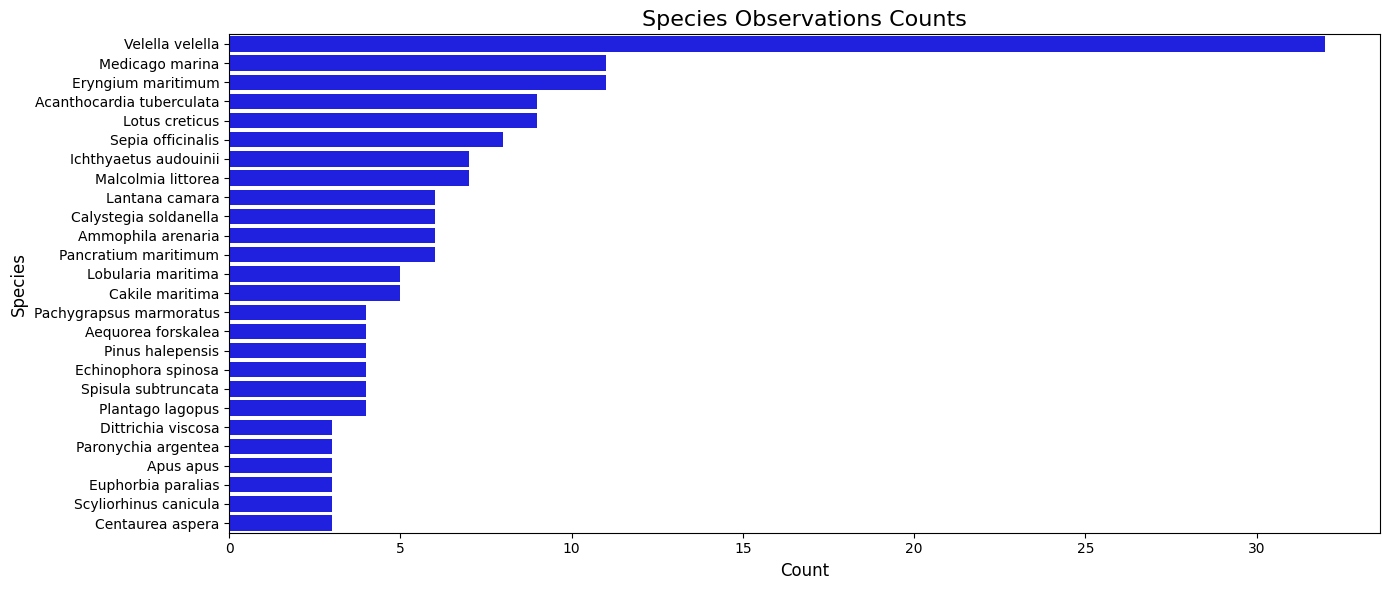

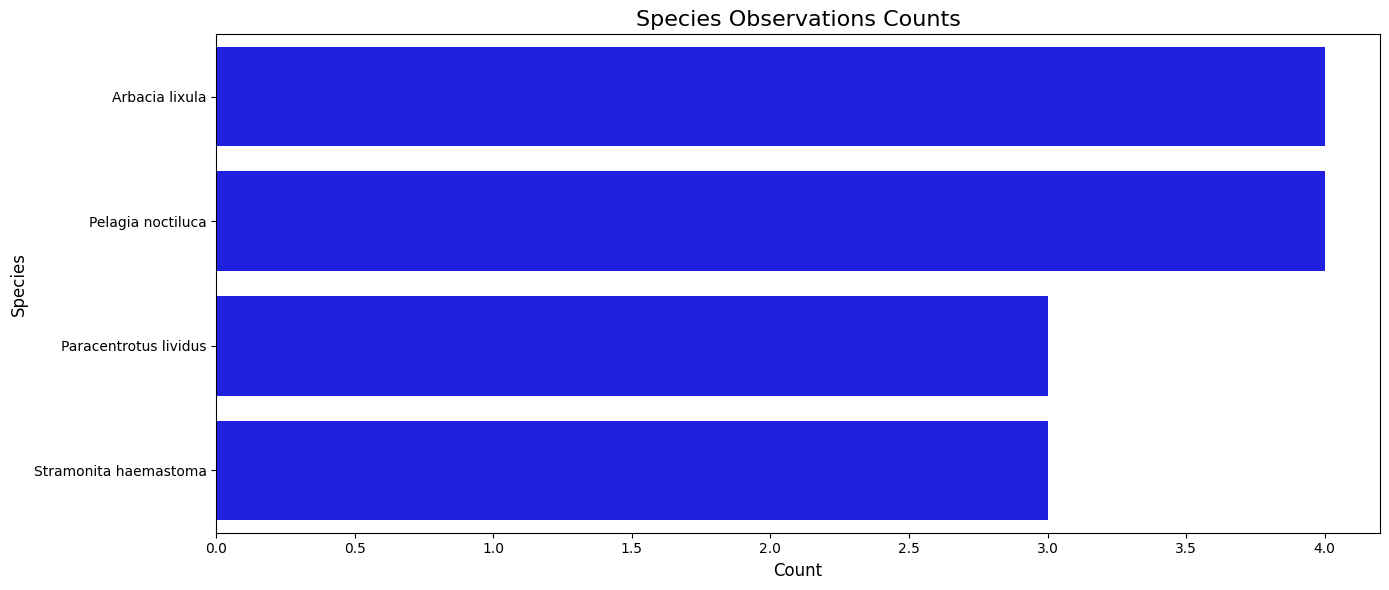

In [31]:
df_species_tm, df_species_lm= get_sum_species_month(264)
plot_species_counts(df_species_tm,'species_count1')
plot_species_counts(df_species_lm, 'species_count2') 

In [ ]:
def get_top_species(project_id: int):

    '''Esta función recibe el id del proyecto junto al numero de especies observadas que se quieren visualizar
    y devuelve el top con las especies más observadas que tengan quality_grade en 'research' '''

    month = datetime.date.today().month
    year = datetime.date.today().year
    species = f'{api_path}/observations/species_counts?'

    url_species_tm = f'{species}&project_id={project_id}&month={month}&year={year-1}&quality_grade=research'
    url_species_lm = f'{species}&project_id={project_id}&month={month}&year={year-2}&quality_grade=research'
    
    species_tm = requests.get(url_species_tm).json()['results']
    species_lm = requests.get(url_species_lm).json()['results']

    top_species_tm = []
    top_species_lm = []

    for i in range(5):
        if species_tm[i]['taxon']['rank_level'] == 10 :
            species_name = species_tm[i]['taxon']['name']
            species_count = species_tm[i]['count']
            top_species_tm.append([species_name, species_count])
        else:
            continue
    
    for i in range(5):
        if species_lm[i]['taxon']['rank_level'] == 10 :
            species_name = species_lm[i]['taxon']['name']
            species_count = species_lm[i]['count']
            top_species_lm.append([species_name, species_count])
        else:
            continue
    

    df_top_species_tm = pd.DataFrame(top_species_tm, columns = ['Especie', 'Num de observaciones' ])
    df_top_species_lm = pd.DataFrame(top_species_lm, columns = ['Especie', 'Num de observaciones' ])
    
    return df_top_species_tm, df_top_species_lm

In [35]:
get_top_species(264)

(                     Especie  Num de observaciones
 0            Velella velella                    32
 1            Medicago marina                    11
 2         Eryngium maritimum                    11
 3  Acanthocardia tuberculata                     9
 4             Lotus creticus                     9,
                  Especie  Num de observaciones
 0         Arbacia lixula                     4
 1      Pelagia noctiluca                     4
 2  Paracentrotus lividus                     3
 3  Stramonita haemastoma                     3
 4      Sepia officinalis                     2)

In [36]:
def plot_top_species(dataframe:pd.DataFrame, filename:str):

    plt.figure(figsize=(14, 6))
    sns.barplot(data = dataframe , 
                 y = 'Especie',
                 x = 'Num de observaciones',
                color = 'blue',
                )
    plt.title('Top 5 Species Observations Counts', fontsize = 16)
    plt.xlabel('Count', fontsize = 12)
    plt.ylabel('Species', fontsize = 12)
    plt.tight_layout()
    plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight')
    return plt.show()

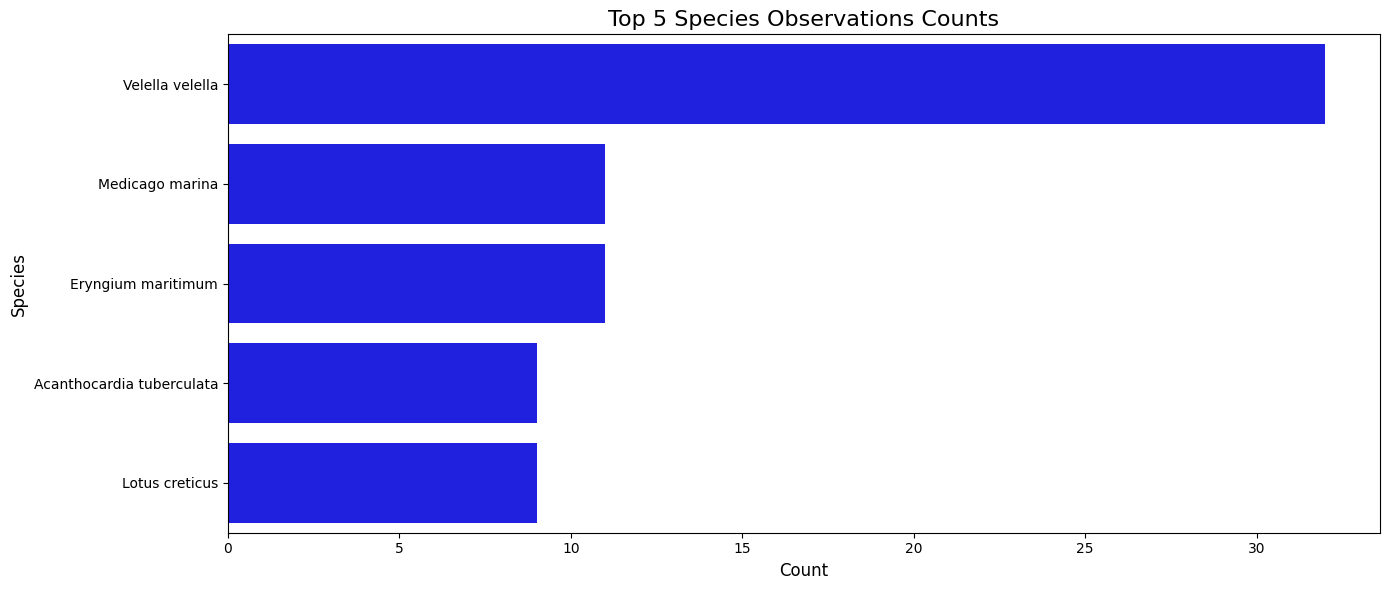

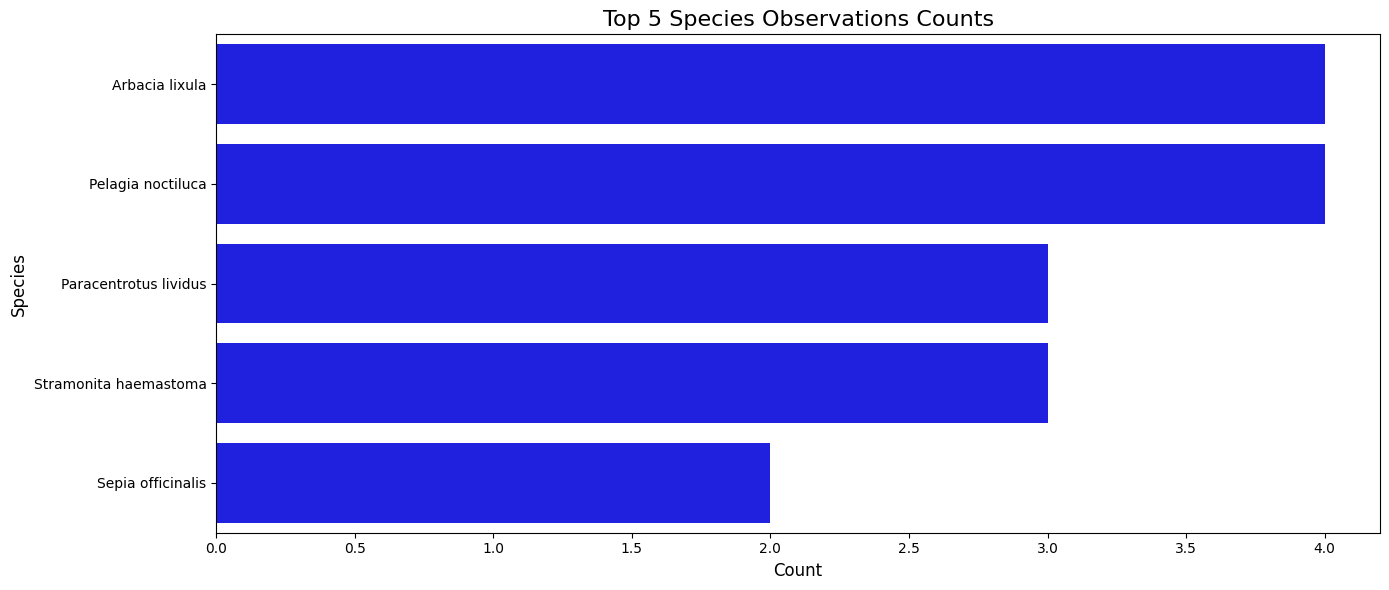

In [37]:
df_top_species_tm, df_top_species_lm = get_top_species(264)
plot_top_species(df_top_species_tm,'top_species1')
plot_top_species(df_top_species_lm,'top_species2')

IDENTIFICADORES

In [ ]:
def get_total_identifiers(project_id:int, year:int):

    if year >= 2021 and year <= datetime.date.today().year:

        identifiers = f'{api_path}/observations/identifiers?'
        url_identifiers = f'{identifiers}&project_id={project_id}&year={year}&quality_grade=research'
        
        total_identifiers = requests.get(url_identifiers).json()["total_results"]

        return total_identifiers

    else:
        print('Year is not valid. Please enter a year between 2021 and the current year.')

In [ ]:
get_total_identifiers(264, 2024)

In [44]:
def get_total_identifiers_month(project_id:int):
    
    year = datetime.date.today().year
    month = datetime.date.today().month

    identifiers = f'{api_path}/observations/identifiers?'
    
    url_identifiers_tm = f'{identifiers}&project_id={project_id}&month={month}&year={year}&quality_grade=research'
    url_identifiers_lm = f'{identifiers}&project_id={project_id}&month={month}&year={year-1}&quality_grade=research'
    
    total_identifiers_tm = requests.get(url_identifiers_tm).json()['total_results']
    total_identifiers_lm = requests.get(url_identifiers_lm).json()['total_results']

    sum_identifiers_tm = requests.get(url_identifiers_tm).json()['results']
    sum_identifiers_lm = requests.get(url_identifiers_lm).json()['results']

    identfiers_tm = []
    identifiers_lm = []
    
    for i in range (len(sum_identifiers_tm)):
        count = sum_identifiers_tm[i]['count']
        name = sum_identifiers_tm[i]['user']['login']
        identfiers_tm.append([name, count])
    
    for i in range (len(sum_identifiers_lm)):
        count = sum_identifiers_lm[i]['count']
        name = sum_identifiers_lm[i]['user']['login']
        identifiers_lm.append([name, count])

    df_identifiers_tm = pd.DataFrame(identfiers_tm, columns=['Identifier', 'Count'])
    df_identifiers_lm = pd.DataFrame(identifiers_lm, columns=['Identifier', 'Count'])


    return df_identifiers_tm, df_identifiers_lm

In [45]:
get_total_identifiers_month(264)

(    Identifier  Count
 0      xasalva     27
 1       badosa      8
 2  jaume-piera      7
 3        jrm92      1,
           Identifier  Count
 0            xasalva    230
 1        jaume-piera     70
 2      guillemdavila     54
 3             badosa     19
 4   loreto_rodriguez     18
 5        amb_platges     17
 6              lydia     10
 7                max      8
 8              rocaj      5
 9         bertinhaco      3
 10        elibonfill      3
 11             yespi      2
 12          ealcaniz      2
 13        uriborrajo      2
 14      jdiazcalafat      2
 15           piripip      1
 16        francismpp      1
 17        vivesgadea      1
 18          laiaamss      1)

In [41]:
def plot_identifiers_counts(dataframe:pd.DataFrame, filename:str):
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data = dataframe , 
                 y = 'Identifier',
                 x = 'Count',
                color = 'blue',
                )
    plt.title('Identifiers Counts', fontsize = 16)
    plt.xlabel('Count', fontsize = 12)
    plt.ylabel('Identifiers', fontsize = 12)
    plt.tight_layout()
    plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight')
    return plt.show()

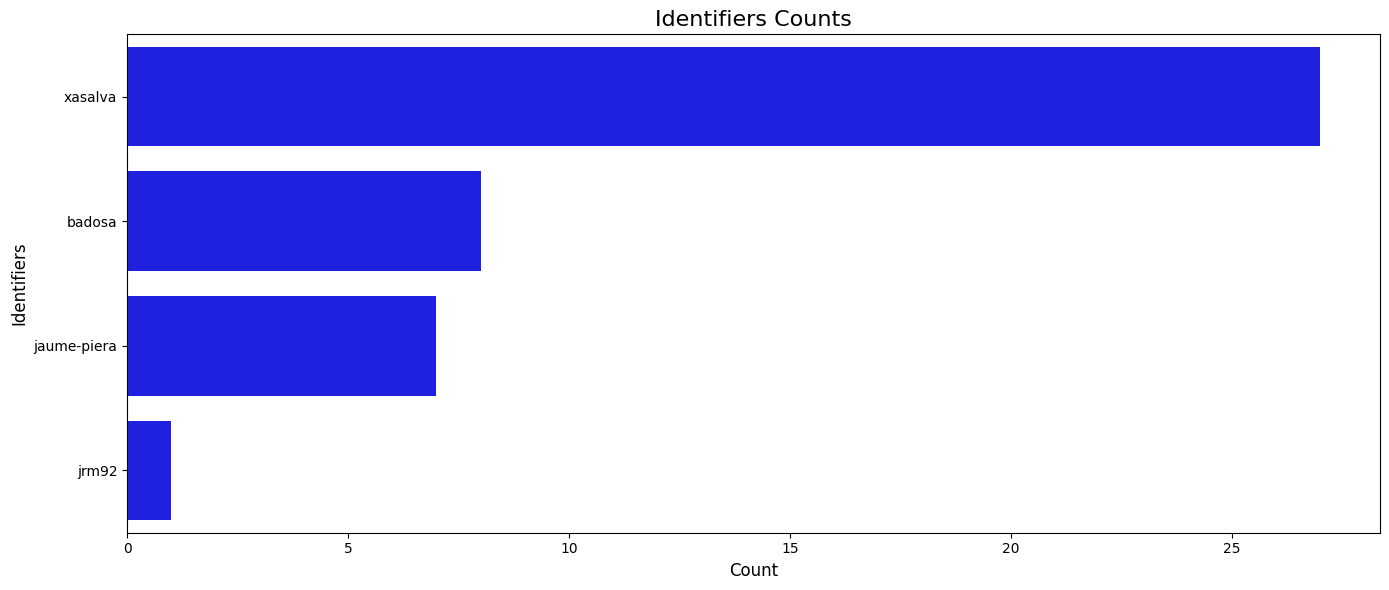

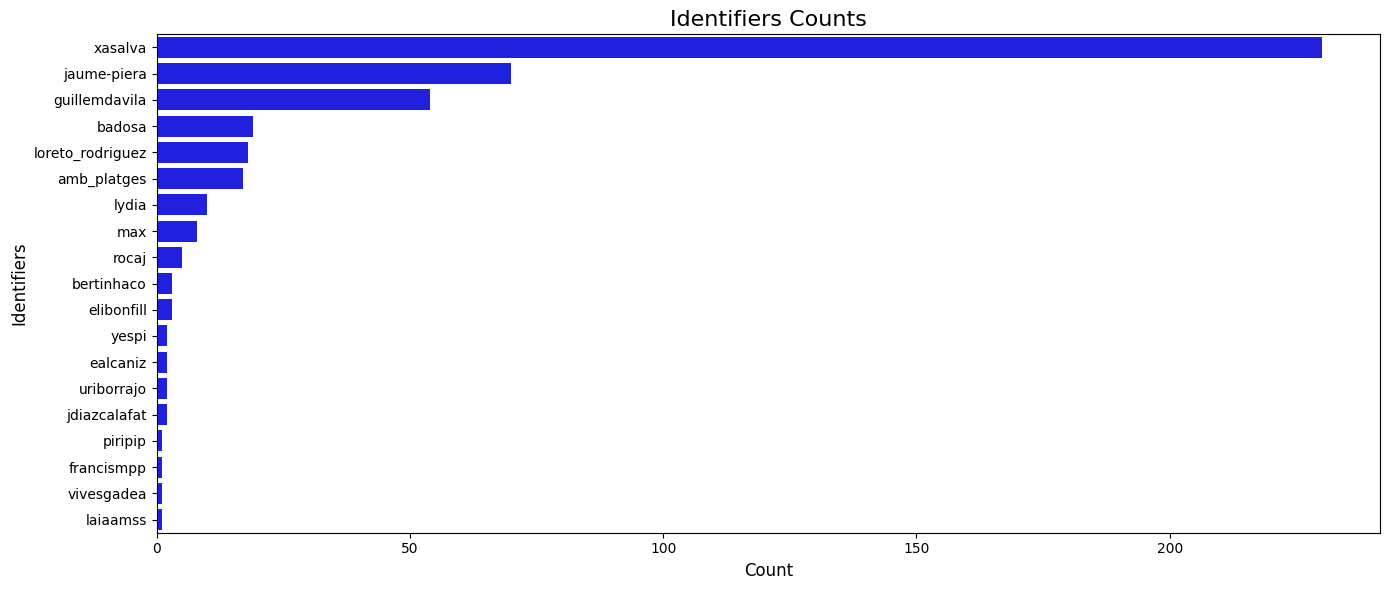

In [46]:
df_identifiers_tm, df_identifiers_lm = get_total_identifiers_month(264)
plot_identifiers_counts(df_identifiers_tm, 'identifiers_count1')
plot_identifiers_counts(df_identifiers_lm, 'identifiers_count2')  

In [48]:
def get_top_identifiers(project_id:int):

    month = datetime.date.today().month
    year = datetime.date.today().year 

    identifiers = f'{api_path}/observations/identifiers?'

    url_identifiers_tm = f'{identifiers}&project_id={project_id}&month={month}&year={year-1}&quality_grade=research'
    url_identifiers_lm = f'{identifiers}&project_id={project_id}&month={month}&year={year-2}&quality_grade=research'

    identifiers_tm = requests.get(url_identifiers_tm).json()['results']
    identifiers_lm = requests.get(url_identifiers_lm).json()['results']

    top_identifiers_tm = []
    top_identifiers_lm = []

    for i in range(5):
        count = identifiers_tm[i]['count']
        name = identifiers_tm[i]['user']['login']
        top_identifiers_tm.append([name, count])

    for i in range(5):
        count = identifiers_lm[i]['count']
        name = identifiers_lm[i]['user']['login']
        top_identifiers_lm.append([name, count])

    df_top_identifiers_tm = pd.DataFrame(top_identifiers_tm, columns = ['Identificador', 'Num de observaciones' ])
    df_top_identifiers_lm = pd.DataFrame(top_identifiers_lm, columns = ['Identificador', 'Num de observaciones' ])

    return df_top_identifiers_tm, df_top_identifiers_lm


In [51]:
get_top_identifiers(264)

(      Identificador  Num de observaciones
 0           xasalva                   230
 1       jaume-piera                    70
 2     guillemdavila                    54
 3            badosa                    19
 4  loreto_rodriguez                    18,
     Identificador  Num de observaciones
 0         xasalva                    25
 1      mariia_vm7                    11
 2  lausanchezvila                     7
 3          vicent                     7
 4           rocaj                     6)

In [55]:
def plot_top_identfiers(dataframe:pd.DataFrame, filename:str):

    plt.figure(figsize=(14, 6))
    sns.barplot(data = dataframe , 
                 y = 'Identificador',
                 x = 'Num de observaciones',
                color = 'blue',
                )
    plt.title('Top 5 Identifiers Counts', fontsize = 16)
    plt.xlabel('Count', fontsize = 12)
    plt.ylabel('Identifiers', fontsize = 12)
    plt.tight_layout()
    plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight')
    return plt.show()

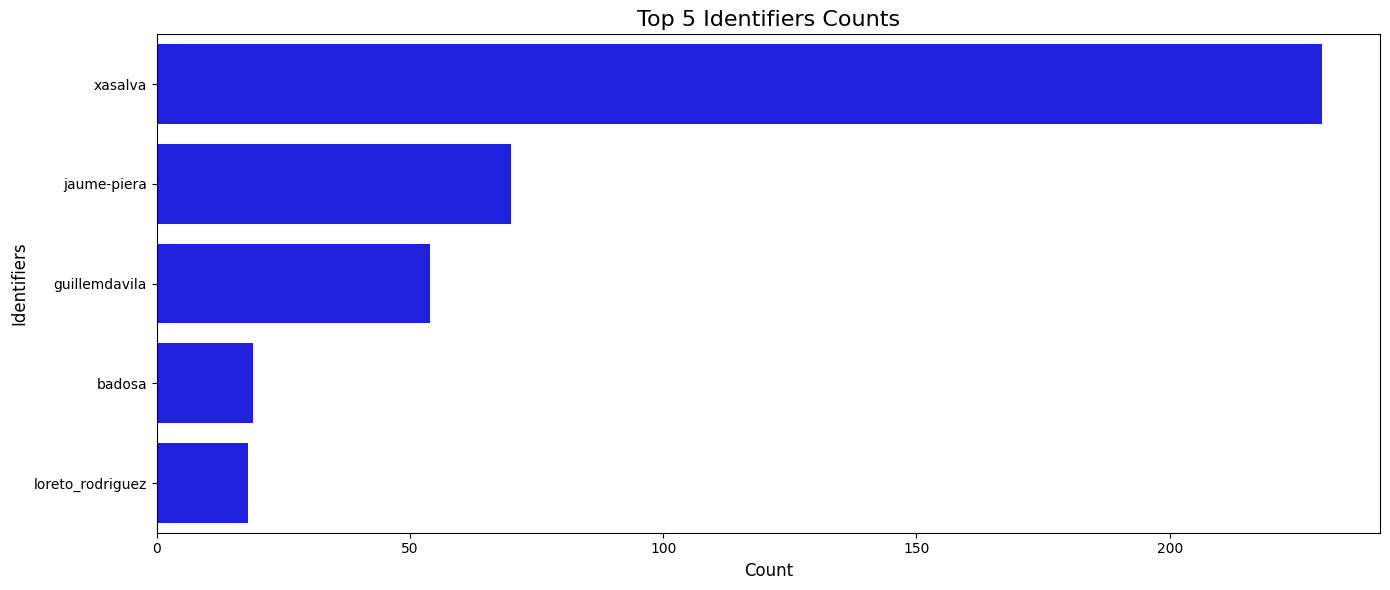

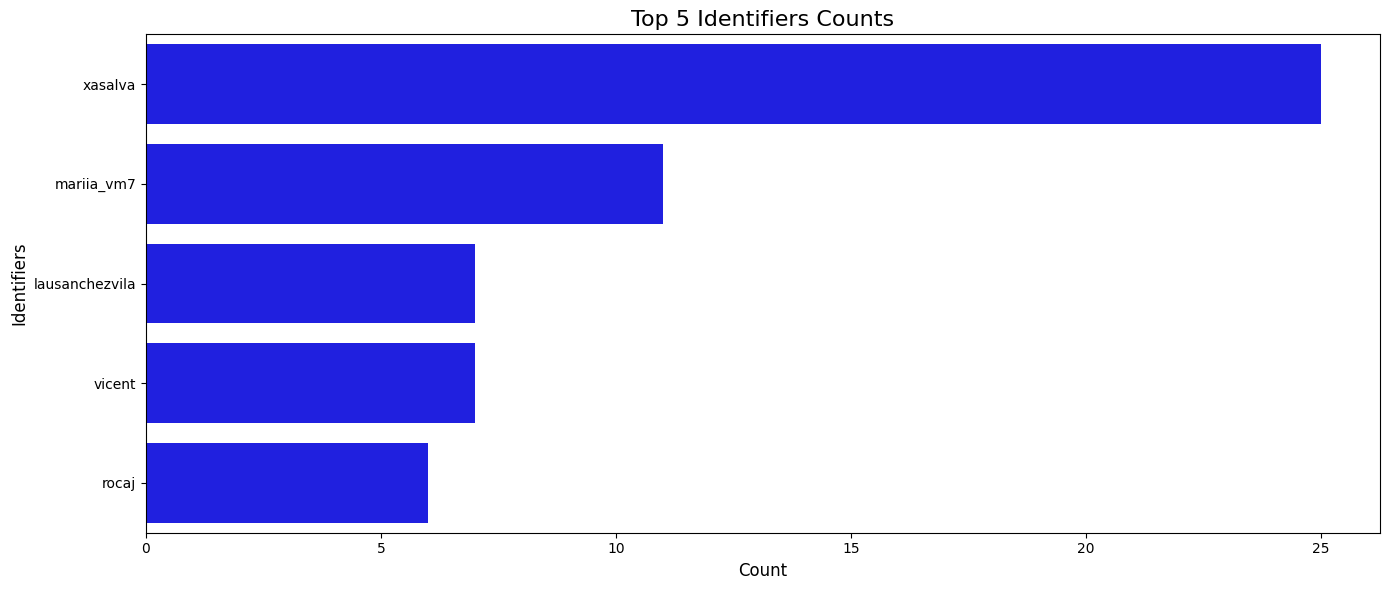

In [56]:
df_top_identifiers_tm, df_top_identifiers_lm = get_top_identifiers(264)
plot_top_identfiers(df_top_identifiers_tm, 'top_identifiers1')
plot_top_identfiers(df_top_identifiers_lm, 'top_identifiers2')


OBSERVADORES

In [ ]:
def get_total_observers(project_id:int, year:int):

    if year >= 2021 and year <= datetime.date.today().year:

        observers = f'{api_path}/observations/observers?'
        url_observers = f'{observers}&project_id={project_id}&year={year}&quality_grade=research'
        
        total_observers = requests.get(url_observers).json()["total_results"]

        return total_observers

    else:
        print('Year is not valid. Please enter a year between 2021 and the current year.')

In [ ]:
get_total_observers(264, 2024)

In [59]:
def get_total_observers_month(project_id:int):
    
    year = datetime.date.today().year
    month = datetime.date.today().month

    observers = f'{api_path}/observations/observers?'
    
    url_observers_tm = f'{observers}&project_id={project_id}&month={month}&year={year}&quality_grade=research'
    url_observers_lm = f'{observers}&project_id={project_id}&month={month}&year={year-1}&quality_grade=research'
    
    total_observers_tm = requests.get(url_observers_tm).json()['total_results']
    total_observers_lm = requests.get(url_observers_lm).json()['total_results']

    sum_observers_tm = requests.get(url_observers_tm).json()['results']
    sum_observers_lm = requests.get(url_observers_lm).json()['results']

    observers_tm = []
    observers_lm = []
    
    for i in range (len(sum_observers_tm)):
        obs_count = sum_observers_tm[i]['observation_count']
        species_count = sum_observers_tm[i]['species_count']
        name = sum_observers_tm[i]['user']['login']
        observers_tm.append([name, obs_count, species_count])
    
    for i in range (len(sum_observers_lm)):
        obs_count = sum_observers_lm[i]['observation_count']
        species_count = sum_observers_lm[i]['species_count']
        name = sum_observers_lm[i]['user']['login']
        observers_lm.append([name, obs_count, species_count])

    df_observers_tm = pd.DataFrame(observers_tm, columns=['Observer', 'Observations Count', 'Species Count'])
    df_observers_lm = pd.DataFrame(observers_lm, columns=['Observer', 'Observations Count', 'Species Count'])


    return df_observers_tm, df_observers_lm

In [60]:
get_total_observers_month(264)

(               Observer  Observations Count  Species Count
 0  mediambient_ajelprat                  22             21
 1           amb_platges                  21             16,
                        Observer  Observations Count  Species Count
 0          mediambient_ajelprat                  96             61
 1                    elibonfill                  44             33
 2              loreto_rodriguez                  32             23
 3                    bertinhaco                  26             24
 4                   amb_platges                  23             13
 5                marinatorresgi                  10              8
 6   romu_freediving_photography                   8              7
 7                     elisabetd                   6              6
 8                        ainhoa                   5              5
 9                       prdsoul                   4              4
 10                        sebas                   4              4
 11

In [ ]:
def plot_observer_metrics(df):

    df_melted = df.melt(id_vars='Observer', 
                        value_vars=['Observations Count', 'Species Count'],
                        var_name='Metric',
                        value_name='Count')

   
    plt.figure(figsize=(14, 8))
    sns.barplot(data=df_melted, x='Observer', y='Count', hue='Metric', palette='Set2')

    plt.xticks(rotation=45, ha='right')
    plt.title('Observaciones y especies por observador')
    plt.xlabel('Observador')
    plt.ylabel('Cantidad')
    plt.tight_layout()
    plt.savefig('observers_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

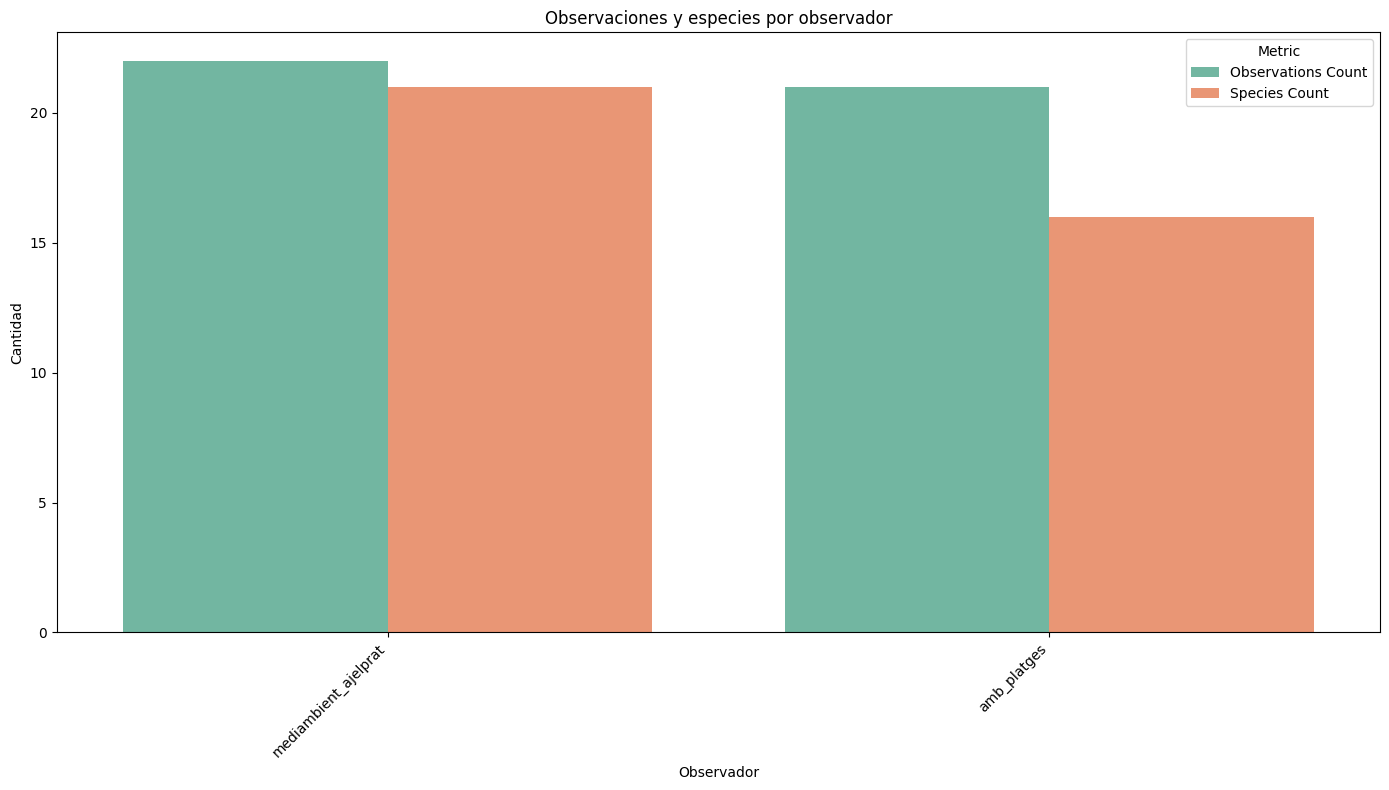

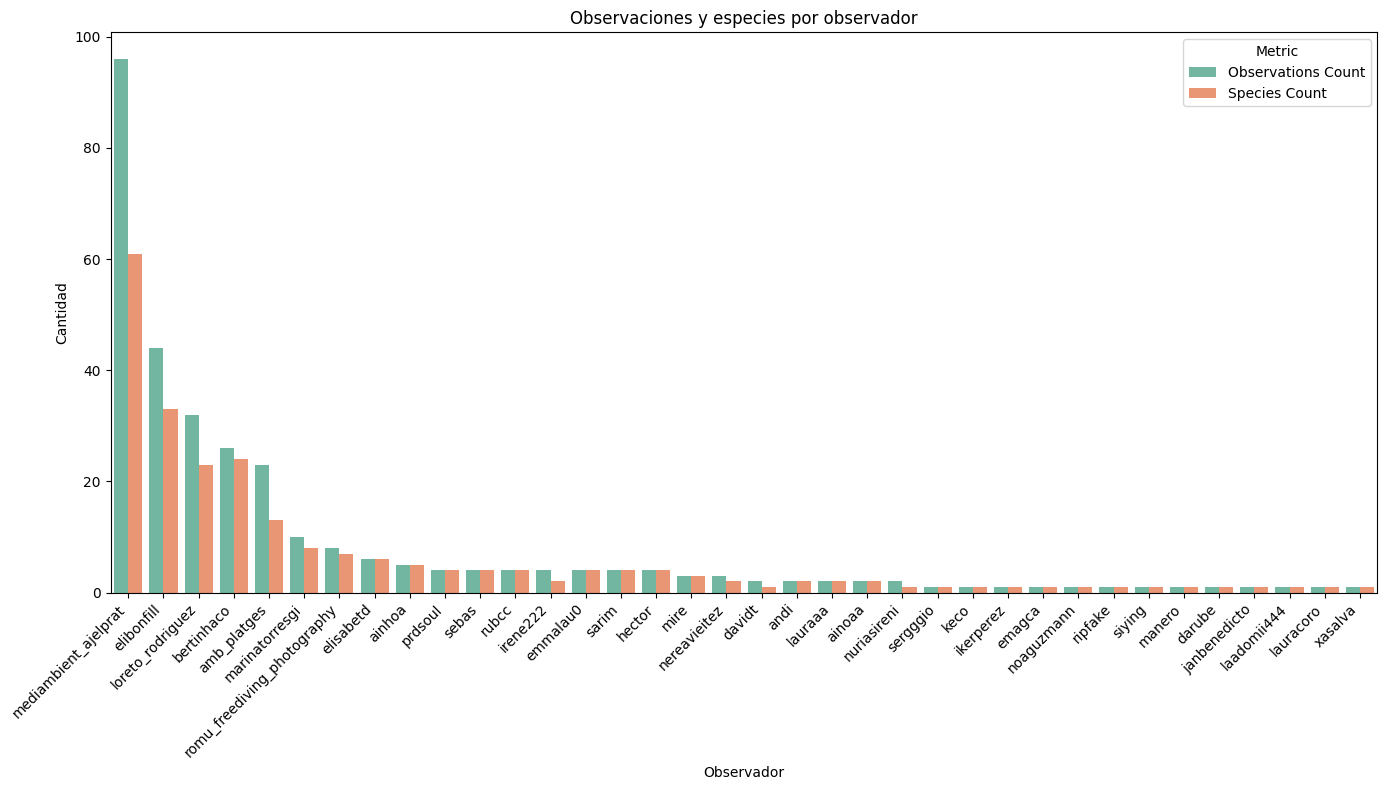

In [62]:
df_tm, df_lm = get_total_observers_month(264)
plot_observer_metrics(df_tm)
plot_observer_metrics(df_lm)

In [ ]:
def get_top_observers(project_id:int):

    month = datetime.date.today().month
    year = datetime.date.today().year 

    observers = f'{api_path}/observations/observers?'

    url_observers_tm = f'{observers}&project_id={project_id}&month={month}&year={year-1}&quality_grade=research'
    url_observers_lm = f'{observers}&project_id={project_id}&month={month}&year={year-2}&quality_grade=research'

    observers_tm = requests.get(url_observers_tm).json()['results']
    observers_lm = requests.get(url_observers_lm).json()['results']

    top_observers_tm = []
    top_observers_lm = []

    for i in range(5):
        obs_count = observers_tm[i]['observation_count']
        species_count = observers_tm[i]['species_count']
        name = observers_tm[i]['user']['login']
        top_observers_tm.append([name, obs_count, species_count])

    for i in range(5):
        obs_count = observers_lm[i]['observation_count']
        species_count = observers_lm[i]['species_count']
        name = observers_lm[i]['user']['login']
        top_observers_lm.append([name, obs_count, species_count])

    df_top_observers_tm = pd.DataFrame(top_observers_tm, columns=['Observer', 'Observations Count', 'Species Count'])
    df_top_observers_lm = pd.DataFrame(top_observers_lm, columns=['Observer', 'Observations Count', 'Species Count'])

    return df_top_observers_tm, df_top_observers_lm
    
    

In [ ]:
get_top_observers(264)

Tercera parte : Metricas relacionadas con los grupos taxonomicos más mapa de calor

In [11]:
def get_data_taxon(project_id:int, taxon:str):
    
    today = datetime.date.today()

    df_obs_ty = pd.DataFrame(get_obs(id_project=project_id, grade = 'research',year = today.year, taxon=taxon))
    dates_ty = pd.to_datetime(df_obs_ty[4].map(lambda x: x[1]))

    df_obs_ly = pd.DataFrame(get_obs(id_project=project_id, grade = 'research',year = today.year - 1, taxon=taxon))
    dates_ly = pd.to_datetime(df_obs_ly[4].map(lambda x: x[1]))

    return dates_ty, dates_ly

In [12]:
get_data_taxon(264, 'Aves')

Generating list of observations:
https://api.minka-sdg.org/v1/observations?project_id=264&iconic_taxa=Aves&year=2025&quality_grade=research&per_page=200
Total observations to download: 111
Number of elements: 111
Generating list of observations:
https://api.minka-sdg.org/v1/observations?project_id=264&iconic_taxa=Aves&year=2024&quality_grade=research&per_page=200
Total observations to download: 353
Number of elements: 200
Number of elements: 353


(0     2025-04-17
 1     2025-04-10
 2     2025-04-10
 3     2025-04-10
 4     2025-04-10
          ...    
 106   2025-01-13
 107   2025-01-13
 108   2025-01-09
 109   2025-01-07
 110   2025-01-07
 Name: 4, Length: 111, dtype: datetime64[ns],
 0     2024-12-20
 1     2024-12-20
 2     2024-12-20
 3     2024-12-19
 4     2024-12-17
          ...    
 348   2024-01-05
 349   2024-01-04
 350   2024-01-04
 351   2024-01-04
 352   2024-01-04
 Name: 4, Length: 353, dtype: datetime64[ns])

In [ ]:
def get_taxon_data(project_id:int, iconic_taxa:str):

    observations = f'{api_path}/observations?'
   
    url_observations_taxa_tm = f'{observations}&project_id={project_id}&month={datetime.date.today().month}&year={datetime.date.today().year}&iconic_taxa={iconic_taxa}&quality_grade=research&per_page=200'
    url_observations_taxa_lm = f'{observations}&project_id={project_id}&month={datetime.date.today().month}&year={datetime.date.today().year-1}&iconic_taxa={iconic_taxa}&quality_grade=research&per_page=200'

    results_taxa_tm = requests.get(url_observations_taxa_tm).json()['results']
    results_taxa_lm = requests.get(url_observations_taxa_lm).json()['results']

    
    return pd.DataFrame(results_taxa_tm), pd.DataFrame(results_taxa_lm)



In [ ]:
def get_coordinates_data(project_id:int, iconic_taxa:str):

    observations = f'{api_path}/observations?'
   
    url_observations_taxa_tm = f'{observations}&project_id={project_id}&month={datetime.date.today().month}&year={datetime.date.today().year}&iconic_taxa={iconic_taxa}&quality_grade=research&per_page=200'
    url_observations_taxa_lm = f'{observations}&project_id={project_id}&month={datetime.date.today().month}&year={datetime.date.today().year-1}&iconic_taxa={iconic_taxa}&quality_grade=research&per_page=200'

    results_taxa_tm = requests.get(url_observations_taxa_tm).json()['results']
    results_taxa_lm = requests.get(url_observations_taxa_lm).json()['results']

    coordinates_tm = []
    coordinates_lm = []


        
    for i in range(len(results_taxa_tm)):
        coords = results_taxa_tm[i].get('geojson', {}).get('coordinates', [])
        if len(coords) >= 2:
            coordinates_tm.append({'lat': coords[1], 'lon': coords[0]})


    for i in range(len(results_taxa_lm)):
        coords = results_taxa_lm[i].get('geojson', {}).get('coordinates', [])
        if len(coords) >= 2:
            coordinates_lm.append({'lat': coords[1], 'lon': coords[0]})

    
    return pd.DataFrame(coordinates_tm), pd.DataFrame(coordinates_lm)



In [ ]:
get_coordinates_data(264, 'Aves')

In [ ]:
def plot_heatmap(dataframe:pd.DataFrame):
    
    m = folium.Map(location=[np.mean(dataframe['lat'].tolist()), np.mean(dataframe['lon'].tolist())], zoom_start=11)

    heat_data = list(zip(dataframe['lat'],dataframe['lon']))
    HeatMap(heat_data).add_to(m)

    return m

In [ ]:
coordinates_tm, coordinates_lm = get_coordinates_data(264,'Plantae')
plot_heatmap(coordinates_lm)
plot_heatmap(coordinates_tm)

Cuarta parte final : CREACIÓN DOCUMENTO

In [ ]:
#def get_docx()

doc = Document()

styles = doc.styles

doc.add_heading('Minka Project', level=1)
heading1_style = styles['Heading 1']
heading1_style.font.name = 'TimesNewRoman'
heading1_style.font.size = Pt(18)

doc.add_paragraph('This document contains the results of the analysis of your Minka project.')

heading2_style = styles['Heading 2']
heading2_style.font.name = 'TimesNewRoman'
heading2_style.font.size = Pt(14)
doc.add_paragraph('Comparation of observations between years')
doc.add_paragraph('This section contains the comparation of observations between years.')
doc.add_paragraph('The first plot shows the distribution of observations in 2024 and the second one shows the distribution of observations in 2025.')
doc.add_picture('obs_2024.png', width=Inches(5.5))
doc.add_picture('obs_2025.png', width=Inches(5.5))

doc.add_page_break()


doc.add_paragraph('This section contains the comparation of species between months.')
doc.add_paragraph('The first plot shows the distribution of species in 2024 and the second one shows the distribution of species in 2025.')
doc.add_picture('species_count1.png', width=Inches(5.5))
doc.add_picture('species_count2.png', width=Inches(5.5))


doc.add_paragraph('This section contains the comparation of top species between years.')
doc.add_paragraph('The first plot shows top species in 2024 and the second one shows the distribution of top species in 2025.')
doc.add_picture('top_species1.png', width=Inches(5.5))
doc.add_picture('top_species2.png', width=Inches(5.5))

doc.add_page_break()

doc.add_paragraph('This section contains the comparation of identifiers between months.')
doc.add_paragraph('The first plot shows the distribution of identifiers in 2024 and the second one shows the distribution of identifiers in 2025.')
doc.add_picture('identifiers_count1.png', width=Inches(5.5))
doc.add_picture('identifiers_count2.png', width=Inches(5.5))


doc.add_page_break()

doc.add_paragraph('This section contains the comparation of top identifiers between years.')
doc.add_paragraph('The first plot shows top identifiers in 2024 and the second one shows the distribution of top identifiers in 2025.')
doc.add_picture('top_identifiers1.png', width=Inches(5.5))
doc.add_picture('top_identifiers2.png', width=Inches(5.5))













doc.save('Doc_Test.docx')